<a href="https://colab.research.google.com/github/NandhithaMilkuri/Nandhitha1352ADM/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('Customers.csv')

In [8]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income ($)',
       'Spending Score (1-100)', 'Profession', 'Work Experience',
       'Family Size'],
      dtype='object')


In [13]:
features = ['Age', 'Annual Income ($)', 'Spending Score (1-100)']  # Adjust column names
X = df[features]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

In [16]:
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])

In [17]:
if 'Customer Segmentation' in df.columns:
    pca_df['Segment'] = df['Customer Segmentation']
else:
    pca_df['Segment'] = 'Unknown'

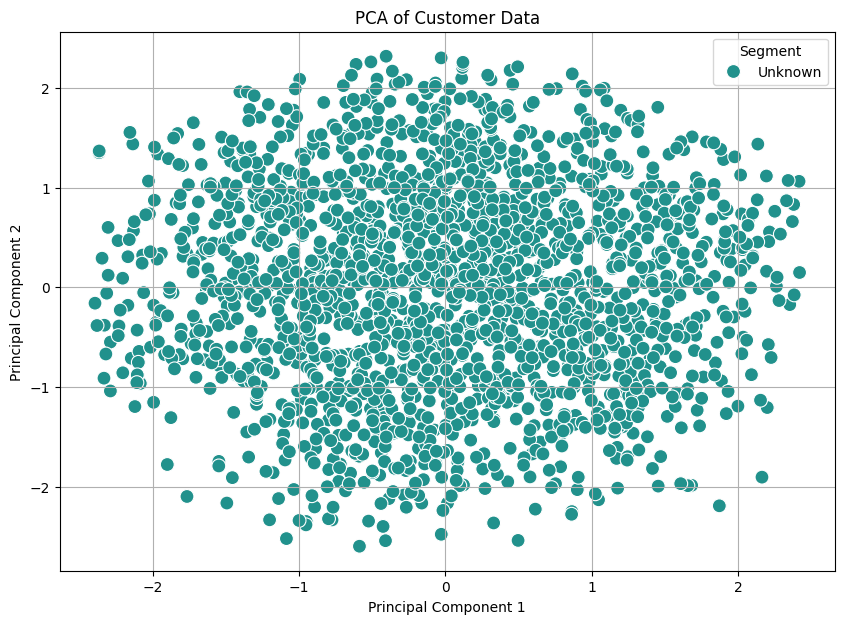

In [18]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Segment', palette='viridis', s=100)
plt.title('PCA of Customer Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [19]:
from sklearn.cluster import KMeans


In [20]:
kmeans = KMeans(n_clusters=5, random_state=42)
pca_df['Cluster'] = kmeans.fit_predict(pca_components)

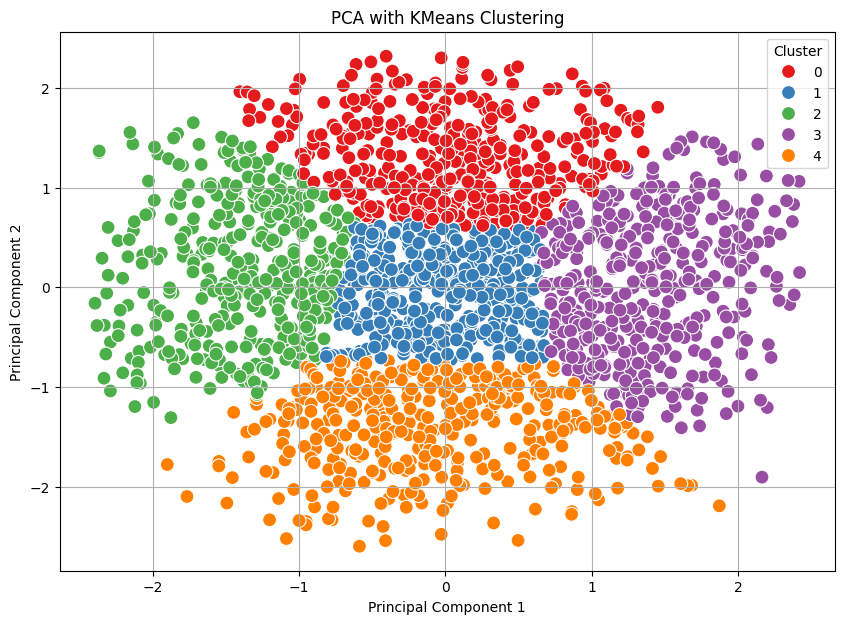

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=100)
plt.title('PCA with KMeans Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()